<img src="https://github.com/litahu/Rendimiento_E-commerce/blob/main/Sprint_1/IMAGES/LOGO_END.png?raw=true" alt="inserir alt">



---

**Elaborado por:** Lita Huánuco | litahume.data@gmail.com

---




### **Historia de fondo**

Tienda Aurelión es una gran minorista que atiende algunas provincias de Córdova a través de su e-commerce. Es conocida por la amplia variedad de productos que ofrece, buscando satisfacer a todo tipo de público desde sus centros de distribución (CDs).

La tienda Aurelión atraviesa una situación crítica y necesita tu apoyo para mantenerse operativa. En los últimos meses, ha experimentado un estancamiento en su flujo de caja. Para contribuir a la toma de decisiones estratégicas en su plataforma online, se te proporciona acceso a cuatro bases de datos: clientes, detalle de ventas, productos y ventas.

### **Objetivo**
Análisis y visualizaciones en forma de:

1. **Comportamiento del cliente**
2. **Calidad de la categoría de productos**
3. **Uso del tipo de pago**



---



# **1. Carga y lectura de datos**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url_clientes = 'https://raw.githubusercontent.com/litahu/Rendimiento_E-commerce/refs/heads/main/Sprint_1/BD/clientes.csv'
url_detalle_ventas = 'https://raw.githubusercontent.com/litahu/Rendimiento_E-commerce/refs/heads/main/Sprint_1/BD/detalle_ventas.csv'
url_productos = 'https://raw.githubusercontent.com/litahu/Rendimiento_E-commerce/refs/heads/main/Sprint_1/BD/productos.csv'
url_ventas = 'https://raw.githubusercontent.com/litahu/Rendimiento_E-commerce/refs/heads/main/Sprint_1/BD/ventas.csv'

**Clientes**

---



In [ ]:
clientes = pd.read_csv(url_clientes, encoding = 'utf-8')
clientes.head()

,id_cliente,nombre_cliente,email,ciudad,fecha_alta,latitud,longitud
0,1,Mariana Lopez,mariana.lopez@mail.com,Villa Carlos Paz,1/1/2023,-31.4183,-64.4901
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Villa Carlos Paz,2/1/2023,-31.4183,-64.4901
2,3,Hernan Martinez,hernan.martinez@mail.com,Río Cuarto,3/1/2023,-33.1304,-64.3527
3,4,Uma Martinez,uma.martinez@mail.com,Villa Carlos Paz,4/1/2023,-31.4183,-64.4901
4,5,Agustina Flores,agustina.flores@mail.com,Córdoba,5/1/2023,-31.4065,-64.1885


In [ ]:

# List of cities with their coordinates
ciudades_coords = [
   {"ciudad": "Villa Carlos Paz", "latitud": -31.4183, "longitud": -64.4901},
   {"ciudad": "Río Cuarto", "latitud": -33.1304, "longitud": -64.3527},
   {"ciudad": "Córdoba", "latitud": -31.4065, "longitud": -64.1885},
   {"ciudad": "Villa María", "latitud": -32.4075, "longitud": -63.2402},
   {"ciudad": "Alta Gracia", "latitud": -31.6498, "longitud": -64.4297},
   {"ciudad": "Mendiolaza", "latitud": -31.2641, "longitud": -64.3091}
]

# Create a DataFrame from the list of cities and coordinates
coords_df = pd.DataFrame(ciudades_coords)

# Merge the clientes DataFrame with the coordinates DataFrame, handling potential duplicate columns
# First, ensure 'clientes' DataFrame is loaded. Assuming it's loaded from url_clientes.
# If not, you might need to load it here:
# clientes = pd.read_csv(url_clientes) # Uncomment if clientes is not loaded

# Drop existing latitud and longitud columns from clientes if they exist, to avoid conflicts during merge
clientes = clientes.drop(columns=['latitud', 'longitud'], errors='ignore')

# Merge with the coordinates DataFrame
clientes = pd.merge(clientes, coords_df, on='ciudad', how='left')


display(clientes.head())

,id_cliente,nombre_cliente,email,ciudad,fecha_alta,latitud,longitud
0,1,Mariana Lopez,mariana.lopez@mail.com,Villa Carlos Paz,1/1/2023,-31.4183,-64.4901
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Villa Carlos Paz,2/1/2023,-31.4183,-64.4901
2,3,Hernan Martinez,hernan.martinez@mail.com,Río Cuarto,3/1/2023,-33.1304,-64.3527
3,4,Uma Martinez,uma.martinez@mail.com,Villa Carlos Paz,4/1/2023,-31.4183,-64.4901
4,5,Agustina Flores,agustina.flores@mail.com,Córdoba,5/1/2023,-31.4065,-64.1885


In [ ]:
clientes.info()
print( f'\nSu forma es:')
clientes.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_cliente      100 non-null    int64  
 1   nombre_cliente  100 non-null    object 
 2   email           100 non-null    object 
 3   ciudad          100 non-null    object 
 4   fecha_alta      100 non-null    object 
 5   latitud         100 non-null    float64
 6   longitud        100 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 5.6+ KB

Su forma es:


(100, 7)

**Detalle ventas**

---



In [ ]:
detalle_ventas = pd.read_csv(url_detalle_ventas, encoding = 'utf-8')
detalle_ventas.head()

,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
0,1,90,Toallas Húmedas x50,1,2902,2902
1,2,82,Aceitunas Negras 200g,5,2394,11970
2,2,39,Helado Vainilla 1L,5,469,2345
3,2,70,Fernet 750ml,2,4061,8122
4,2,22,Medialunas de Manteca,1,2069,2069


In [ ]:
detalle_ventas.info()
print( f'\nSu forma es:')
detalle_ventas.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_venta         343 non-null    int64 
 1   id_producto      343 non-null    int64 
 2   nombre_producto  343 non-null    object
 3   cantidad         343 non-null    int64 
 4   precio_unitario  343 non-null    int64 
 5   importe          343 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 16.2+ KB

Su forma es:


(343, 6)

In [ ]:
detalle_ventas.columns

Index(['id_venta', 'id_producto', 'nombre_producto', 'cantidad',
       'precio_unitario', 'importe'],
      dtype='object')

**Productos**

---



In [ ]:
producto = pd.read_csv(url_productos, encoding = 'utf-8')
producto.head()

,id_producto,nombre_producto,categoria,precio_unitario
0,1,Coca Cola 1.5L,Alimentos,2347
1,2,Pepsi 1.5L,Limpieza,4973
2,3,Sprite 1.5L,Alimentos,4964
3,4,Fanta Naranja 1.5L,Limpieza,2033
4,5,Agua Mineral 500ml,Alimentos,4777


In [ ]:
producto.info()
print( f'\nSu forma es:')
producto.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_producto      100 non-null    int64 
 1   nombre_producto  100 non-null    object
 2   categoria        100 non-null    object
 3   precio_unitario  100 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB

Su forma es:


(100, 4)

**Ventas**

---



In [ ]:
venta = pd.read_csv(url_ventas, encoding = 'utf-8')
venta.head()

,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr
2,3,2024-01-13,20,Tomas Acosta,tomas.acosta@mail.com,tarjeta
3,4,2024-02-27,36,Martina Molina,martina.molina@mail.com,transferencia
4,5,2024-06-11,56,Bruno Diaz,bruno.diaz@mail.com,tarjeta


In [ ]:
venta.info()
print( f'\nSu forma es:')
venta.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_venta        120 non-null    int64 
 1   fecha           120 non-null    object
 2   id_cliente      120 non-null    int64 
 3   nombre_cliente  120 non-null    object
 4   email           120 non-null    object
 5   medio_pago      120 non-null    object
dtypes: int64(2), object(4)
memory usage: 5.8+ KB

Su forma es:


(120, 6)

In [ ]:
# Reload the clientes DataFrame from the corrected CSV to ensure updated dates
try:
    clientes = pd.read_csv('/content/archivo_corregido.csv', encoding='utf-8')
    # Convert fecha_alta to datetime, coercing errors
    clientes['fecha_alta'] = pd.to_datetime(clientes['fecha_alta'], errors='coerce')
except FileNotFoundError:
    print("Error: 'archivo_corregido.csv' not found. Please ensure cell CfS1TBgmHy2H was executed successfully.")
    # If file not found, proceed with the existing clientes DataFrame but inform the user
    pass # This will allow the rest of the cell to attempt execution with the current 'clientes'


# Ensure the client ID column name is consistent
if 'ï»¿id_cliente' in clientes.columns:
    clientes.rename(columns={'ï»¿id_cliente': 'id_cliente'}, inplace=True)

# Merge venta and detalle_ventas on 'id_venta'
merged_df = pd.merge(venta, detalle_ventas, on='id_venta', how='inner')

# Merge the result with producto on 'id_producto'
merged_df = pd.merge(merged_df, producto, on='id_producto', how='inner')

# Check if latitud and longitud columns exist in clientes before creating subset
if 'latitud' not in clientes.columns or 'longitud' not in clientes.columns:
    print("Warning: 'latitud' or 'longitud' columns not found in the 'clientes' DataFrame.")
    print("Attempting to merge with coordinates DataFrame.")
    # List of cities with their coordinates (from region.PNG)
    ciudades_coords = [
        {"ciudad": "Villa Carlos Paz", "latitud": -31.4183, "longitud": -64.4901},
        {"ciudad": "Río Cuarto", "latitud": -33.1304, "longitud": -64.3527},
        {"ciudad": "Córdoba", "latitud": -31.4065, "longitud": -64.1885},
        {"ciudad": "Villa Maria", "latitud": -32.4075, "longitud": -63.2402},
        {"ciudad": "Alta Gracia", "latitud": -31.6498, "longitud": -64.4297},
        {"ciudad": "Mendiolaza", "latitud": -31.2641, "longitud": -64.3091}
    ]
    coords_df = pd.DataFrame(ciudades_coords)
    clientes = pd.merge(clientes.drop(columns=['latitud', 'longitud'], errors='ignore'), coords_df, on='ciudad', how='left')
    if 'latitud' not in clientes.columns or 'longitud' not in clientes.columns:
         print("Error: Could not add latitude and longitude to 'clientes'. Please check the cities and coordinate data.")


# Merge the result with clients on 'id_cliente'
# An inner merge is used here (how='inner') to only include rows where 'id_cliente' exists in both DataFrames.
if 'id_cliente' in clientes.columns and 'ciudad' in clientes.columns and 'fecha_alta' in clientes.columns and 'latitud' in clientes.columns and 'longitud' in clientes.columns:
    clientes_subset = clientes[['id_cliente', 'ciudad', 'fecha_alta', 'latitud', 'longitud']].copy()
    merged_df = pd.merge(merged_df, clientes_subset, on='id_cliente', how='inner')

    # Define the desired column order
    desired_order = [
        'id_venta',
        'fecha',
        'id_cliente',
        'nombre_cliente',
        'email',
        'medio_pago',
        'id_producto',
        'nombre_producto_x', # nombre_producto from detalle_ventas
        'categoria',
        'precio_unitario_y', # precio_unitario from producto
        'cantidad',
        'importe',
        'ciudad',
        'fecha_alta',
        'latitud',
        'longitud'
    ]

    # Reorder the columns
    merged_df = merged_df[desired_order]

    # Display the first few rows of the merged DataFrame
    display(merged_df.head())
else:
    print("Error: Required columns for merging from 'clientes' are missing after processing.")

Error: 'archivo_corregido.csv' not found. Please ensure cell CfS1TBgmHy2H was executed successfully.


,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago,id_producto,nombre_producto_x,categoria,precio_unitario_y,cantidad,importe,ciudad,fecha_alta,latitud,longitud
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta,90,Toallas Húmedas x50,Limpieza,2902,1,2902,Villa Carlos Paz,3/3/2023,-31.4183,-64.4901
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,82,Aceitunas Negras 200g,Limpieza,2394,5,11970,Río Cuarto,18/2/2023,-33.1304,-64.3527
2,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,39,Helado Vainilla 1L,Alimentos,469,5,2345,Río Cuarto,18/2/2023,-33.1304,-64.3527
3,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,70,Fernet 750ml,Limpieza,4061,2,8122,Río Cuarto,18/2/2023,-33.1304,-64.3527
4,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,22,Medialunas de Manteca,Limpieza,2069,1,2069,Río Cuarto,18/2/2023,-33.1304,-64.3527


In [ ]:
merged_df.info()
print( f'\nSu forma es:')
merged_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_venta           343 non-null    int64  
 1   fecha              343 non-null    object 
 2   id_cliente         343 non-null    int64  
 3   nombre_cliente     343 non-null    object 
 4   email              343 non-null    object 
 5   medio_pago         343 non-null    object 
 6   id_producto        343 non-null    int64  
 7   nombre_producto_x  343 non-null    object 
 8   categoria          343 non-null    object 
 9   precio_unitario_y  343 non-null    int64  
 10  cantidad           343 non-null    int64  
 11  importe            343 non-null    int64  
 12  ciudad             343 non-null    object 
 13  fecha_alta         343 non-null    object 
 14  latitud            343 non-null    float64
 15  longitud           343 non-null    float64
dtypes: float64(2), int64(6), o

(343, 16)

In [ ]:
merged_df.to_csv('/content/sample_data/merged_aurelion.csv', index=False, sep=';')

In [ ]:
df= pd.read_csv('/content/sample_data/merged_aurelion.csv', encoding = 'utf-8', delimiter=';')
df.head()

,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago,id_producto,nombre_producto_x,categoria,precio_unitario_y,cantidad,importe,ciudad,fecha_alta,latitud,longitud
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta,90,Toallas Húmedas x50,Limpieza,2902,1,2902,Villa Carlos Paz,3/3/2023,-31.4183,-64.4901
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,82,Aceitunas Negras 200g,Limpieza,2394,5,11970,Río Cuarto,18/2/2023,-33.1304,-64.3527
2,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,39,Helado Vainilla 1L,Alimentos,469,5,2345,Río Cuarto,18/2/2023,-33.1304,-64.3527
3,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,70,Fernet 750ml,Limpieza,4061,2,8122,Río Cuarto,18/2/2023,-33.1304,-64.3527
4,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr,22,Medialunas de Manteca,Limpieza,2069,1,2069,Río Cuarto,18/2/2023,-33.1304,-64.3527


In [ ]:
df.info()
print( f'\nSu forma es:')
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_venta           343 non-null    int64  
 1   fecha              343 non-null    object 
 2   id_cliente         343 non-null    int64  
 3   nombre_cliente     343 non-null    object 
 4   email              343 non-null    object 
 5   medio_pago         343 non-null    object 
 6   id_producto        343 non-null    int64  
 7   nombre_producto_x  343 non-null    object 
 8   categoria          343 non-null    object 
 9   precio_unitario_y  343 non-null    int64  
 10  cantidad           343 non-null    int64  
 11  importe            343 non-null    int64  
 12  ciudad             343 non-null    object 
 13  fecha_alta         343 non-null    object 
 14  latitud            343 non-null    float64
 15  longitud           343 non-null    float64
dtypes: float64(2), int64(6), o

(343, 16)

# **2. Limpieza de datos**

In [ ]:
data_null = (df.isna().sum()/len(df)).sort_values(ascending=False)
pd.set_option('display.max_rows', None)
data_null

,0
id_venta,0.0
fecha,0.0
id_cliente,0.0
nombre_cliente,0.0
email,0.0
medio_pago,0.0
id_producto,0.0
nombre_producto,0.0
categoria,0.0
precio_unitario,0.0


In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.columns:
    if df[col].dtypes != 'object':
        print("{} : {} unique val".format(col, df[col].nunique()))
        print("sample values: {}".format(df[col].unique()[:5]))
        print('-'*100)

id_venta : 120 unique val
sample values: [1 2 3 4 5]
----------------------------------------------------------------------------------------------------
id_cliente : 67 unique val
sample values: [62 49 20 36 56]
----------------------------------------------------------------------------------------------------
id_producto : 95 unique val
sample values: [90 82 39 70 22]
----------------------------------------------------------------------------------------------------
precio_unitario_y : 94 unique val
sample values: [2902 2394  469 4061 2069]
----------------------------------------------------------------------------------------------------
cantidad : 5 unique val
sample values: [1 5 2 4 3]
----------------------------------------------------------------------------------------------------
importe : 249 unique val
sample values: [ 2902 11970  2345  8122  2069]
----------------------------------------------------------------------------------------------------
latitud : 6 unique val


In [ ]:

for col in df.columns:
    if df[col].dtypes == 'object':
        print("{} : {} unique val".format(col, df[col].nunique()))
        print("sample values: {}".format(df[col].unique()))
        print('-'*100)

fecha : 93 unique val
sample values: ['2024-06-19' '2024-03-17' '2024-01-13' '2024-02-27' '2024-06-11'
 '2024-05-05' '2024-05-06' '2024-01-06' '2024-01-20' '2024-05-28'
 '2024-04-10' '2024-06-28' '2024-01-24' '2024-04-18' '2024-06-27'
 '2024-04-12' '2024-02-17' '2024-05-08' '2024-05-16' '2024-06-14'
 '2024-04-30' '2024-01-23' '2024-02-25' '2024-05-20' '2024-02-20'
 '2024-03-03' '2024-05-22' '2024-01-30' '2024-02-13' '2024-05-30'
 '2024-06-25' '2024-05-17' '2024-05-29' '2024-03-05' '2024-05-13'
 '2024-03-08' '2024-02-18' '2024-02-21' '2024-01-19' '2024-03-25'
 '2024-05-04' '2024-01-26' '2024-06-02' '2024-01-09' '2024-05-10'
 '2024-01-25' '2024-03-26' '2024-01-04' '2024-01-10' '2024-02-04'
 '2024-04-28' '2024-04-04' '2024-06-01' '2024-05-01' '2024-03-07'
 '2024-03-14' '2024-03-21' '2024-02-02' '2024-04-26' '2024-05-23'
 '2024-05-15' '2024-05-26' '2024-04-29' '2024-06-06' '2024-03-09'
 '2024-01-02' '2024-04-20' '2024-06-21' '2024-01-18' '2024-01-08'
 '2024-02-19' '2024-02-09' '2024-01-29'

In [ ]:
df.replace(to_replace= ['tarjeta'], value = 'Tarjeta', inplace=True)
df.replace(to_replace= ['qr'], value = 'QR', inplace=True)
df.replace(to_replace= ['transferencia'], value = 'Transferencia', inplace=True)
df.replace(to_replace= ['efectivo'], value = 'Efectivo', inplace=True)

---
**Los datos incorrectos:**

<img src="https://github.com/litahu/Rendimiento_E-commerce/blob/main/Sprint_2/evidence/problem_dat.PNG?raw=true" alt="inserir alt">


In [ ]:
# Diccionario de categorías y productos
categorias = {
    'Limpieza': [
        'Toallas Húmedas x50', 'Trapo de Piso', 'Lavandina 1L', 'Limpiavidrios 500ml', 'Desodorante Aerosol',
        'Shampoo 400ml', 'Desengrasante 500ml', 'Papel Higiénico x4', 'Mascarilla Capilar', 'Crema Dental 90g',
        'Cepillo de Dientes', 'Detergente Líquido 750ml', 'Jabón de Tocador', 'Servilletas x100', 'Hilo Dental'
    ],
    'Abarrotes': [
        'Caldo Concentrado Verdura', 'Stevia 100 sobres', 'Azúcar 1kg', 'Salsa de Tomate 500g',
        'Vinagre de Alcohol 500ml', 'Lentejas Secas 500g', 'Chocolate Amargo 100g', 'Leche Descremada 1L',
        'Avena Instantánea 250g', 'Sopa Instantánea Pollo', 'Leche Entera 1L', 'Arroz Largo Fino 1kg',
        'Sal Fina 500g', 'Aceite de Girasol 1L', 'Café Molido 250g', 'Caldo Concentrado Carne',
        'Porotos Negros 500g', 'Fideos Spaghetti 500g', 'Harina de Trigo 1kg', 'Garbanzos 500g',
        'Yerba Mate Intensa 1kg', 'Yerba Mate Suave 1kg', 'Dulce de Leche 400g', 'Chocolate con Leche 100g',
        'Jugo en Polvo Limón', 'Té Verde 20 saquitos', 'Té Negro 20 saquitos'
    ],
    'Verduras': ['Verduras Congeladas Mix'],
    'Embutidos': [
        'Aceitunas Negras 200g', 'Medialunas de Manteca', 'Manteca 200g', 'Hamburguesas Congeladas x4',
        'Queso Untable 190g', 'Mermelada de Durazno 400g', 'Mermelada de Frutilla 400g', 'Queso Rallado 150g',
        'Aceitunas Verdes 200g', 'Queso Azul 150g', 'Queso Cremoso 500g', 'Miel Pura 250g',
        'Pizza Congelada Muzzarella', 'Empanadas Congeladas'
    ],
    'Panadería': [
        'Pan Lactal Integral', 'Pan Lactal Blanco', 'Bizcochos Salados', 'Turrón 50g',
        'Alfajor Triple', 'Alfajor Simple'
    ],
    'Dulcería': [
        'Helado Vainilla 1L', 'Galletitas Vainilla', 'Mix de Frutos Secos 200g', 'Chicle Menta',
        'Granola 250g', 'Papas Fritas Clásicas 100g', 'Barrita de Cereal 30g', 'Galletitas Chocolate',
        'Caramelos Masticables', 'Maní Salado 200g', 'Helado Chocolate 1L', 'Helado de Frutilla 1L',
        'Papas Fritas Onduladas 100g'
    ],
    'Bebidas': [
        'Sprite 1.5L', 'Pepsi 1.5L', 'Jugo en Polvo Naranja', 'Fanta Naranja 1.5L', 'Yogur Natural 200g',
        'Coca Cola 1.5L', 'Jugo de Naranja 1L', 'Jugo de Manzana 1L', 'Agua Mineral 500ml', 'Energética Nitro 500ml'
    ],
    'Licores': [
        'Vodka 700ml', 'Cerveza Negra 1L', 'Fernet 750ml', 'Vino Blanco 750ml', 'Cerveza Rubia 1L',
        'Ron 700ml', 'Gin 700ml', 'Vino Tinto Malbec 750ml', 'Whisky 750ml'
    ]
}

# Función para asignar categoría
def asignar_categoria(producto):
    for categoria, productos in categorias.items():
        if producto in productos:
            return categoria
    return 'Sin categoría'

# Aplicar la función al DataFrame
df['categoria'] = df['nombre_producto_x'].apply(asignar_categoria)

In [ ]:

# Lista de columnas de fecha
columnas_fecha = ['fecha', 'fecha_alta']

# Conversión segura con formato inferido y dayfirst
for col in columnas_fecha:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')

In [ ]:
df.info()
print(f'Su forma es: {df.shape}')
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_venta           343 non-null    int64         
 1   fecha              343 non-null    datetime64[ns]
 2   id_cliente         343 non-null    int64         
 3   nombre_cliente     343 non-null    object        
 4   email              343 non-null    object        
 5   medio_pago         343 non-null    object        
 6   id_producto        343 non-null    int64         
 7   nombre_producto_x  343 non-null    object        
 8   categoria          343 non-null    object        
 9   precio_unitario_y  343 non-null    int64         
 10  cantidad           343 non-null    int64         
 11  importe            343 non-null    int64         
 12  ciudad             343 non-null    object        
 13  fecha_alta         343 non-null    datetime64[ns]
 14  latitud   

,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago,id_producto,nombre_producto_x,categoria,precio_unitario_y,cantidad,importe,ciudad,fecha_alta,latitud,longitud
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,Tarjeta,90,Toallas Húmedas x50,Limpieza,2902,1,2902,Villa Carlos Paz,2023-03-03,-31.4183,-64.4901
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,82,Aceitunas Negras 200g,Embutidos,2394,5,11970,Río Cuarto,2023-02-18,-33.1304,-64.3527
2,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,39,Helado Vainilla 1L,Dulcería,469,5,2345,Río Cuarto,2023-02-18,-33.1304,-64.3527
3,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,70,Fernet 750ml,Licores,4061,2,8122,Río Cuarto,2023-02-18,-33.1304,-64.3527
4,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,22,Medialunas de Manteca,Embutidos,2069,1,2069,Río Cuarto,2023-02-18,-33.1304,-64.3527


In [ ]:
df.rename(columns={'precio_unitario_y': 'precio_unitario', 'nombre_producto_x': 'nombre_producto'}, inplace=True)

# **3. Estandarización de valores**

In [ ]:
Q1 = df['importe'].quantile(0.25)
Q3 = df['importe'].quantile(0.75)

def categorizar_valor(importe):
    if importe < Q1:
        return 'Bajo'
    elif importe <= Q3:
        return 'Medio'
    else:
        return 'Alto'

df['Valor_del_Plan'] = df['importe'].apply(categorizar_valor)

In [ ]:

# Lista de columnas a normalizar
columnas_a_normalizar = ['precio_unitario', 'cantidad', 'importe']  # Agrega más si lo necesitas

# Normalizar y mostrar estadísticas por cada variable
for col in columnas_a_normalizar:
    col_norm = f"{col}_normalizado"

    media = df[col].mean()
    desviacion = df[col].std()

    # Normalización con redondeo
    df[col_norm] = round((df[col] - media) / desviacion, 2)

    # Estadísticas redondeadas
    print(f"📊 Estadísticas para '{col}':")
    print(f" Media: {round(media, 2)}")
    print(f" Desviación estándar: {round(desviacion, 2)}")
    print(f" Máximo normalizado: {round(df[col_norm].max(), 2)}")
    print(f" Mínimo normalizado: {round(df[col_norm].min(), 2)}")
    print(f" Máximo original: {round(df[col].max(), 2)}")
    print(f" Mínimo original: {round(df[col].min(), 2)}")
    print("🧩" + "-" * 50)

📊 Estadísticas para 'precio_unitario':
 Media: 2654.5
 Desviación estándar: 1308.69
 Máximo normalizado: 1.78
 Mínimo normalizado: -1.82
 Máximo original: 4982
 Mínimo original: 272
🧩--------------------------------------------------
📊 Estadísticas para 'cantidad':
 Media: 2.96
 Desviación estándar: 1.37
 Máximo normalizado: 1.49
 Mínimo normalizado: -1.44
 Máximo original: 5
 Mínimo original: 1
🧩--------------------------------------------------
📊 Estadísticas para 'importe':
 Media: 7730.08
 Desviación estándar: 5265.54
 Máximo normalizado: 3.25
 Mínimo normalizado: -1.42
 Máximo original: 24865
 Mínimo original: 272
🧩--------------------------------------------------


In [ ]:
# Mostrar resumen del DataFrame final
print("\n📋 Información del DataFrame:")
df.info()


📋 Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_venta                     343 non-null    int64         
 1   fecha                        343 non-null    datetime64[ns]
 2   id_cliente                   343 non-null    int64         
 3   nombre_cliente               343 non-null    object        
 4   email                        343 non-null    object        
 5   medio_pago                   343 non-null    object        
 6   id_producto                  343 non-null    int64         
 7   nombre_producto              343 non-null    object        
 8   categoria                    343 non-null    object        
 9   precio_unitario              343 non-null    int64         
 10  cantidad                     343 non-null    int64         
 11  importe        

In [ ]:
df.head()

,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago,id_producto,nombre_producto,categoria,precio_unitario,cantidad,importe,ciudad,fecha_alta,latitud,longitud,Valor_del_Plan,precio_unitario_normalizado,cantidad_normalizado,importe_normalizado
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,Tarjeta,90,Toallas Húmedas x50,Limpieza,2902,1,2902,Villa Carlos Paz,2023-03-03,-31.4183,-64.4901,Bajo,0.19,-1.44,-0.92
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,82,Aceitunas Negras 200g,Embutidos,2394,5,11970,Río Cuarto,2023-02-18,-33.1304,-64.3527,Alto,-0.20,1.49,0.81
2,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,39,Helado Vainilla 1L,Dulcería,469,5,2345,Río Cuarto,2023-02-18,-33.1304,-64.3527,Bajo,-1.67,1.49,-1.02
3,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,70,Fernet 750ml,Licores,4061,2,8122,Río Cuarto,2023-02-18,-33.1304,-64.3527,Medio,1.07,-0.70,0.07
4,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,22,Medialunas de Manteca,Embutidos,2069,1,2069,Río Cuarto,2023-02-18,-33.1304,-64.3527,Bajo,-0.45,-1.44,-1.08


In [ ]:
print(f'Su forma es: {df.shape}')

Su forma es: (343, 20)


# **4. Tratando valores atípicos**

In [ ]:
df[['cantidad','precio_unitario','importe', 'cantidad_normalizado','precio_unitario_normalizado','importe_normalizado']].describe().round(2)

,cantidad,precio_unitario,importe,cantidad_normalizado,precio_unitario_normalizado,importe_normalizado
count,343.00,343.00,343.00,343.00,343.00,343.00
mean,2.96,2654.50,7730.08,0.00,0.00,-0.00
std,1.37,1308.69,5265.54,1.00,1.00,1.00
min,1.00,272.00,272.00,-1.44,-1.82,-1.42
25%,2.00,1618.50,3489.00,-0.70,-0.79,-0.81
50%,3.00,2512.00,6702.00,0.03,-0.11,-0.20
75%,4.00,3876.00,10231.50,0.76,0.93,0.48
max,5.00,4982.00,24865.00,1.49,1.78,3.25


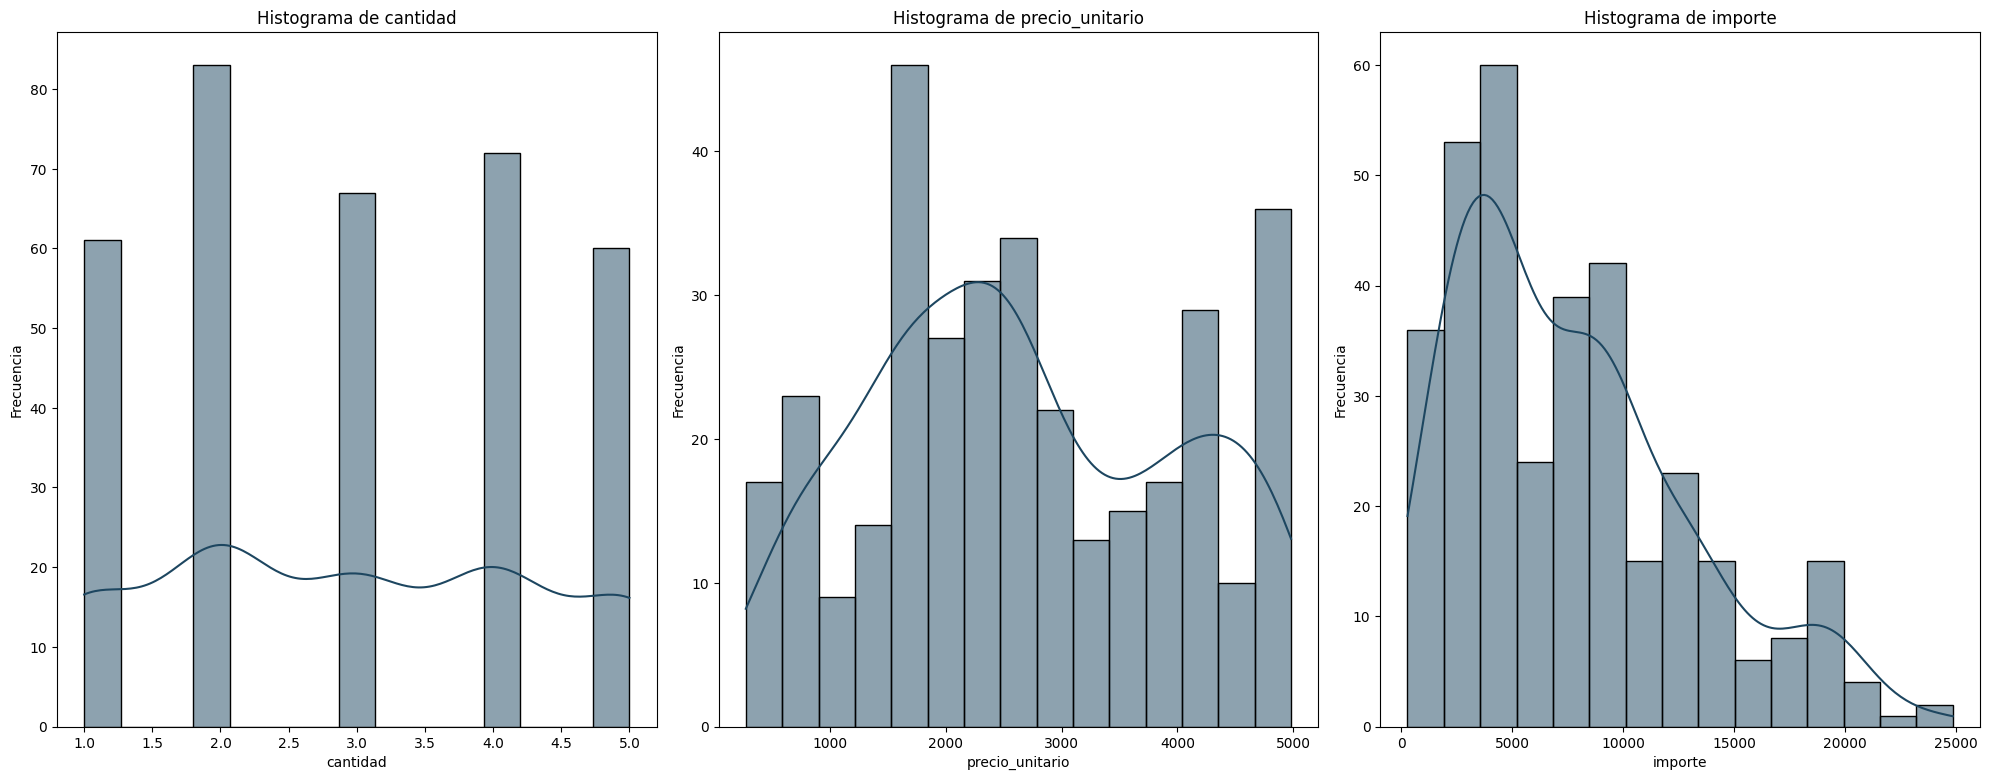

In [ ]:
# Lista de variables a graficar
variables = ['cantidad', 'precio_unitario', 'importe']

# Crear figura
plt.figure(figsize=(20, 15))

# Graficar histogramas
for i, col in enumerate(variables):
    plt.subplot(2, 3, i + 1)  # Ajusta filas y columnas según cantidad
    sns.histplot(df[col], kde=True, color='#1D4660', bins=15)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()

plt.show()

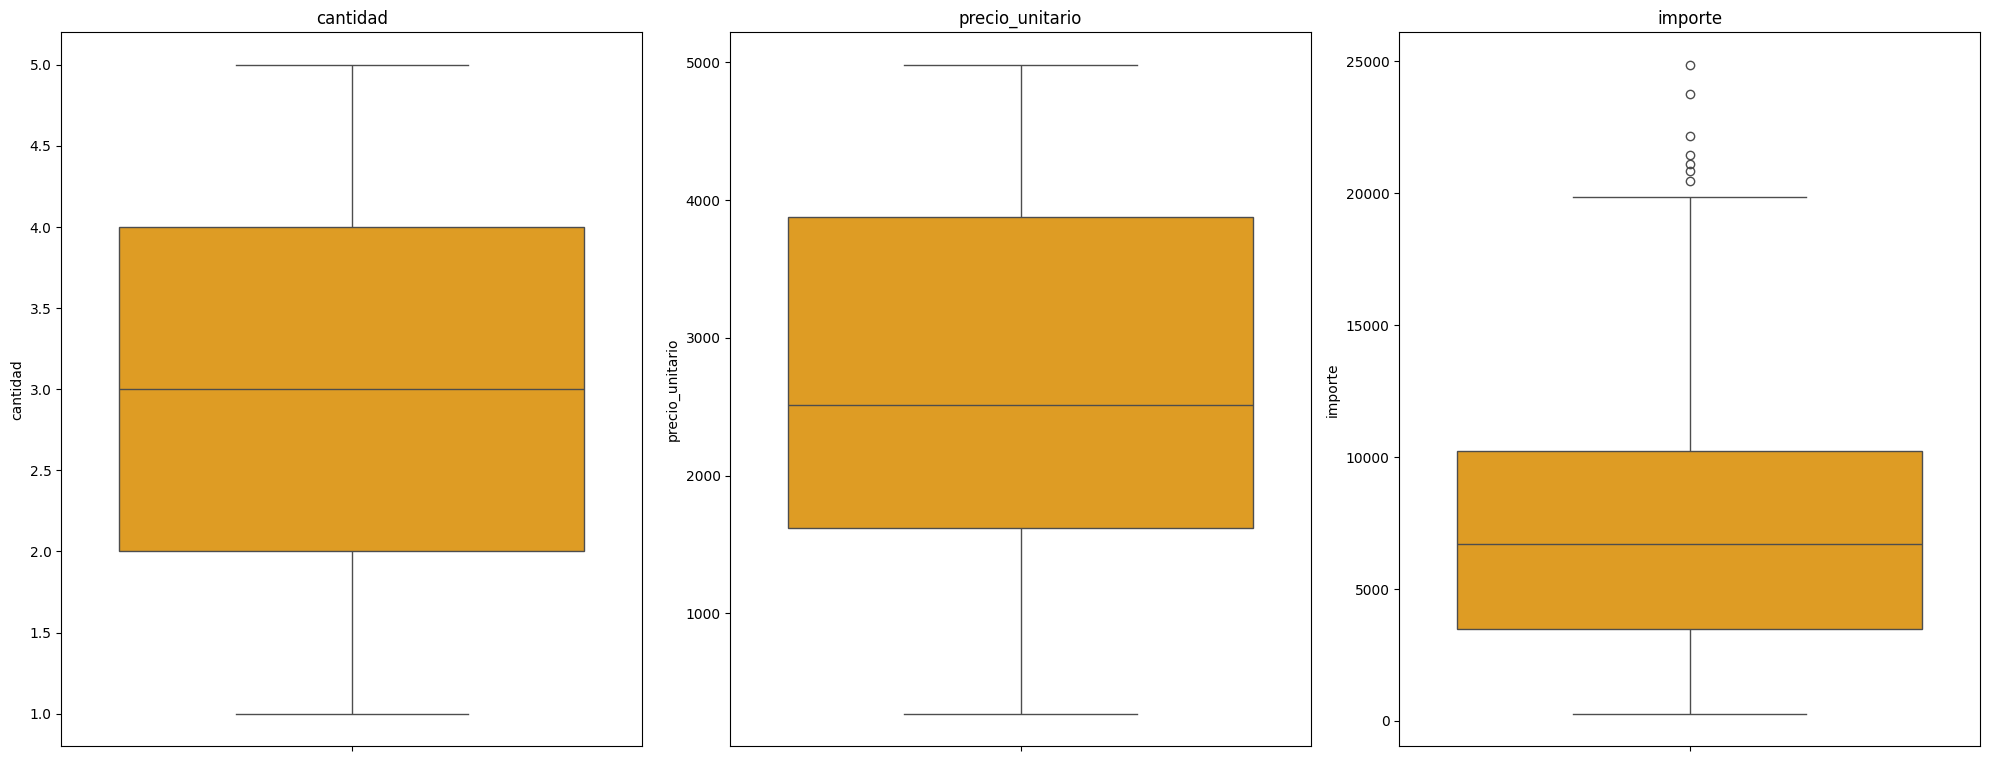

In [ ]:
# Lista de columnas específicas
variables = ['cantidad', 'precio_unitario', 'importe']

# Crear figura
plt.figure(figsize=(20, 15))

# Graficar boxplots por cada variable
for i, col in enumerate(variables):
    plt.subplot(2, 3, i + 1)  # Ajusta filas y columnas según cantidad
    sns.boxplot(y=df[col], orient='v', color= '#FDA505')
    plt.title(col)
    plt.tight_layout()

plt.show()


In [ ]:
# Lista de columnas específicas para detectar outliers
columnas_a_evaluar = ['importe']

# Detectar outliers usando el método IQR
for col in columnas_a_evaluar:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ]

    print(f"📊 Columna: {col}")
    print(f" - Límite inferior: {limite_inferior:.2f}")
    print(f" - Límite superior: {limite_superior:.2f}")
    print(f" - Cantidad de outliers: {len(outliers)}")
    print("🧩" + "-" * 50)

📊 Columna: importe
 - Límite inferior: -6624.75
 - Límite superior: 20345.25
 - Cantidad de outliers: 7
🧩--------------------------------------------------


In [ ]:
outliers=df.sort_values('importe', ascending=False).head(8)
outliers

,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago,id_producto,nombre_producto,categoria,precio_unitario,cantidad,importe,ciudad,fecha_alta,latitud,longitud,Valor_del_Plan,precio_unitario_normalizado,cantidad_normalizado,importe_normalizado
208,75,2024-05-23,61,Guadalupe Martinez,guadalupe.martinez@mail.com,QR,2,Pepsi 1.5L,Bebidas,4973,5,24865,Río Cuarto,2023-03-02,-33.1304,-64.3527,Alto,1.77,1.49,3.25
141,50,2024-01-09,8,Bruno Castro,bruno.castro@mail.com,Transferencia,58,Caramelos Masticables,Dulcería,4752,5,23760,Villa Carlos Paz,2023-01-08,-31.4183,-64.4901,Alto,1.60,1.49,3.04
41,16,2024-04-12,2,Nicolas Rojas,nicolas.rojas@mail.com,Efectivo,35,Barrita de Cereal 30g,Dulcería,4430,5,22150,Villa Carlos Paz,2023-01-02,-31.4183,-64.4901,Alto,1.36,1.49,2.74
54,21,2024-06-19,10,Karina Acosta,karina.acosta@mail.com,Transferencia,76,Pizza Congelada Muzzarella,Embutidos,4286,5,21430,Córdoba,2023-01-10,-31.4065,-64.1885,Alto,1.25,1.49,2.60
175,63,2024-06-19,25,Karina Castro,karina.castro@mail.com,Tarjeta,8,Energética Nitro 500ml,Bebidas,4218,5,21090,Río Cuarto,2023-01-25,-33.1304,-64.3527,Alto,1.19,1.49,2.54
308,110,2024-05-19,92,Mariana Rodriguez,mariana.rodriguez@mail.com,Efectivo,6,Jugo de Naranja 1L,Bebidas,4170,5,20850,Alta Gracia,2023-04-02,-31.6498,-64.4297,Alto,1.16,1.49,2.49
260,94,2024-03-06,41,Elena Rodriguez,elena.rodriguez2@mail.com,QR,86,Jugo en Polvo Limón,Abarrotes,4090,5,20450,Alta Gracia,2023-02-10,-31.6498,-64.4297,Alto,1.10,1.49,2.42
207,75,2024-05-23,61,Guadalupe Martinez,guadalupe.martinez@mail.com,QR,3,Sprite 1.5L,Bebidas,4964,4,19856,Río Cuarto,2023-03-02,-33.1304,-64.3527,Alto,1.76,0.76,2.30


In [ ]:

# Seleccionar las columnas específicas
variables = ['cantidad', 'precio_unitario', 'importe']

# Calcular la matriz de correlación
matriz_correlacion = df[variables].corr(numeric_only=True)

# Mostrar la matriz redondeada a 2 decimales
print(matriz_correlacion.round(2))

                 cantidad  precio_unitario  importe
cantidad             1.00            -0.07     0.60
precio_unitario     -0.07             1.00     0.68
importe              0.60             0.68     1.00


In [ ]:
# Lista de índices a eliminar
#indices_a_eliminar = [208, 141, 76, 8, 6, 86]

# Eliminar las filas del DataFrame
#df.drop(index=indices_a_eliminar, inplace=True)

# Verificar que se eliminaron
#print(f"✅ Se eliminaron las filas con índices: {indices_a_eliminar}")
#print(f"📏 Nueva forma del DataFrame: {df.shape}")

✅ Se eliminaron las filas con índices: [208, 141, 76, 8, 6, 86]
📏 Nueva forma del DataFrame: (337, 20)


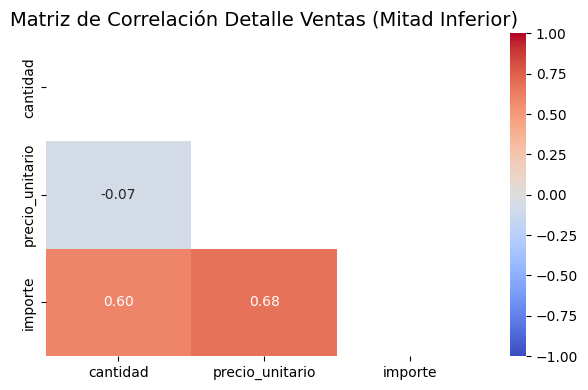

In [ ]:
# Crear una máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

# Crear el heatmap con la máscara aplicada
plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz_correlacion,
    mask=mask,  # aplicar la máscara
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot_kws={'size': 10}
)

# Título y ajustes
plt.title('Matriz de Correlación Detalle Ventas (Mitad Inferior)', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:

df.info()
print(f'\nSu forma es: {df.shape}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_venta                     343 non-null    int64         
 1   fecha                        343 non-null    datetime64[ns]
 2   id_cliente                   343 non-null    int64         
 3   nombre_cliente               343 non-null    object        
 4   email                        343 non-null    object        
 5   medio_pago                   343 non-null    object        
 6   id_producto                  343 non-null    int64         
 7   nombre_producto              343 non-null    object        
 8   categoria                    343 non-null    object        
 9   precio_unitario              343 non-null    int64         
 10  cantidad                     343 non-null    int64         
 11  importe                      343 non-null    

In [ ]:
df.to_csv('aurelion_clean.csv', index=False)

In [ ]:
df.head()

,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago,id_producto,nombre_producto,categoria,precio_unitario,cantidad,importe,ciudad,fecha_alta,latitud,longitud,Valor_del_Plan,precio_unitario_normalizado,cantidad_normalizado,importe_normalizado
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,Tarjeta,90,Toallas Húmedas x50,Limpieza,2902,1,2902,Villa Carlos Paz,2023-03-03,-31.4183,-64.4901,Bajo,0.19,-1.44,-0.92
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,82,Aceitunas Negras 200g,Embutidos,2394,5,11970,Río Cuarto,2023-02-18,-33.1304,-64.3527,Alto,-0.20,1.49,0.81
2,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,39,Helado Vainilla 1L,Dulcería,469,5,2345,Río Cuarto,2023-02-18,-33.1304,-64.3527,Bajo,-1.67,1.49,-1.02
3,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,70,Fernet 750ml,Licores,4061,2,8122,Río Cuarto,2023-02-18,-33.1304,-64.3527,Medio,1.07,-0.70,0.07
4,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,QR,22,Medialunas de Manteca,Embutidos,2069,1,2069,Río Cuarto,2023-02-18,-33.1304,-64.3527,Bajo,-0.45,-1.44,-1.08


# **5. Exploración de los datos**

#### **Comportamiento del cliente**

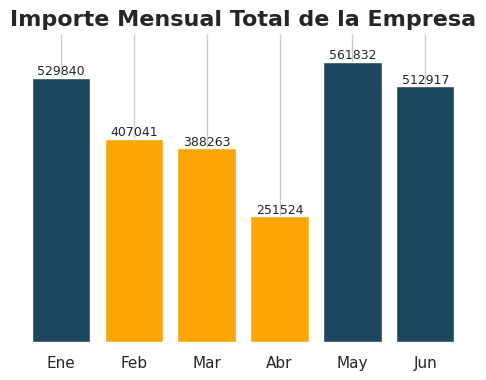

In [ ]:
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun'] # Added 'Jun'
importe = df.groupby('mes')['importe'].sum().sort_index()

# Get the indices of the 3 smallest values
indices_bajos = importe.nsmallest(3).index.tolist()

# Colors
colores = ['#FDA505' if mes in indices_bajos else '#1D4660' for mes in importe.index] # Use month number for comparison

# Create plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(meses_labels, importe, color=colores) # Use meses_labels for x-axis

# Labels over the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{height}', ha='center', va='bottom', fontsize=9) # Removed %

# Remove borders (spines)
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)


# Ocultar la cuadrícula del eje Y
ax.grid(False, axis='y')


# Remove title and Y axis
ax.set_yticks([])  # Remove Y axis ticks
ax.set_ylim(0, max(importe) * 1.1) # Adjust ylim to accommodate labels

plt.title('Importe Mensual Total de la Empresa', fontsize=16, fontweight='bold')
plt.show()

Debido a su estrecha relación con el poder adquisitivo de los hogares, el sector minorista suele reaccionar rápidamente ante cambios económicos. La tercera crisis de deuda que atravesó Argentina en abril tuvo un efecto directo en la contracción del consumo minorista.

In [ ]:
df[['cantidad', 'importe', 'precio_unitario']].describe().round(2)

,cantidad,importe,precio_unitario
count,343.00,343.00,343.00
mean,2.96,7730.08,2654.50
std,1.37,5265.54,1308.69
min,1.00,272.00,272.00
25%,2.00,3489.00,1618.50
50%,3.00,6702.00,2512.00
75%,4.00,10231.50,3876.00
max,5.00,24865.00,4982.00


In [ ]:
# Crear figura con dos subplots: histograma arriba, boxplot abajo
fig = sp.make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.3],
    vertical_spacing=0.05
)

# Histograma
fig.add_trace(
    go.Histogram(
        x=df['importe'],
        nbinsx=30,
        marker_color='#FDA505',
        name='Histograma'
    ),
    row=1, col=1
)

# Boxplot
fig.add_trace(
    go.Box(
        x=df['importe'],
        marker_color='#FDA505',
        boxpoints='outliers',
        name='Boxplot',
        orientation='h'
    ),
    row=2, col=1
)

# Estilo general
fig.update_layout(
    height=600,
    showlegend=False,
    title_text="Distribución del importe",
    title_font=dict(size=16, family='Arial', color='black'),
    margin=dict(t=60, l=40, r=40, b=40),
    plot_bgcolor='white'
)

# Ejes y cuadrícula
fig.update_xaxes(showgrid=True, gridcolor='#F6F6F6', linecolor='#989898', tickfont=dict(color='#4f4f4f'))
fig.update_yaxes(showgrid=False, linecolor='#989898', tickfont=dict(color='#4f4f4f'))

fig.show()

In [ ]:
# Extraer mes como periodo
df['mes'] = df['fecha'].dt.to_period('M')

# Contar pedidos por cliente por mes
pedidos_por_cliente = df.groupby(['mes', 'id_cliente']).size().reset_index(name='pedidos')

# Calcular frecuencia media mensual
frecuencia_media = pedidos_por_cliente.groupby('mes')['pedidos'].mean().reset_index()
frecuencia_media.columns = ['Mes', 'Frecuencia Media']


# Calcular importe total y número de pedidos por mes
resumen_mensual = df.groupby('mes').agg({'importe': 'sum', 'id_cliente': 'count'}).reset_index()
resumen_mensual.columns = ['Mes', 'Importe Total', 'Cantidad Pedidos']

# Calcular ticket promedio mensual
resumen_mensual['Ticket Promedio'] = resumen_mensual['Importe Total'] / resumen_mensual['Cantidad Pedidos']

- Si ambas curvas suben juntas, los clientes están comprando más seguido y gastando más por pedido, lo cual es ideal.

- Si la frecuencia sube pero el ticket baja, puede indicar compras más frecuentes pero de menor valor.

- Si el ticket sube pero la frecuencia baja, los clientes compran menos veces pero gastan más en cada ocasión.



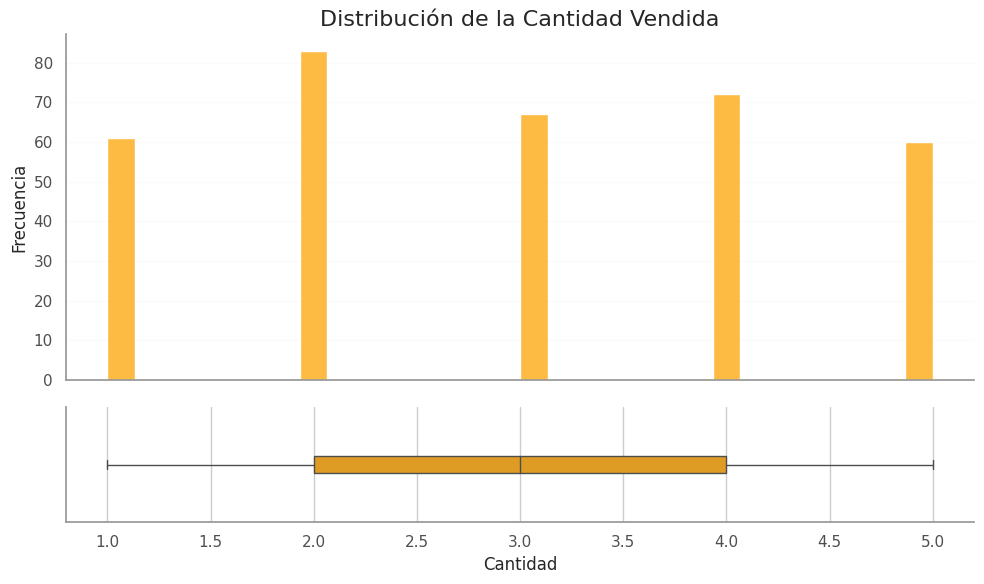

In [ ]:
# Configurar estilo
sns.set(style="whitegrid")

# Crear figura con dos subplots: histograma arriba, boxplot abajo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

# Histograma de la variable 'cantidad'
sns.histplot(data=df, x='cantidad', bins=30, kde=False, ax=ax1, color='#FDA505')
ax1.set_title('Distribución de la Cantidad Vendida', fontsize=16)
ax1.set_xlabel('')
ax1.set_ylabel('Frecuencia')

# Boxplot de la variable 'cantidad'
sns.boxplot(data=df, x='cantidad', ax=ax2, color='#FDA505', width=0.15)
ax2.set_xlabel('Cantidad')
ax2.set_ylabel('')

# Añadir cuadrícula
ax1.grid(True, linestyle='-', alpha=0.5, color='#F6F6F6') # Lower alpha for grid lines

# Eliminar bordes (spines) excepto bottom and left
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

#******LETRA DE LOS EJES
# Ocultar eje X del histograma
ax1.get_xaxis().set_visible(False)

# Set tick parameters with dark grey color --LETRA DE EJE
ax1.tick_params(axis='y', colors='#4f4f4f')
ax2.tick_params(axis='x', colors='#4f4f4f')


# Set the color of the remaining spines----EJES
ax1.spines['bottom'].set_color('#989898')
ax1.spines['left'].set_color('#989898')
ax2.spines['bottom'].set_color('#989898')
ax2.spines['left'].set_color('#989898') # Keep left spine for boxplot


# Ajustar diseño
plt.tight_layout()
plt.show()

In [ ]:
import folium # Import the folium library

# 🎨 Definir colores según Valor_del_Plan
color_map = {
    'Bajo': 'green',
    'Medio': 'orange',
    'Alto': 'red'
}

# 🗺️ Crear el mapa centrado en Córdoba, Argentina
m = folium.Map(location=[-32.0, -64.5], zoom_start=7)

# 🔵 Agregar burbujas al mapa
for i, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=row['importe'] / 1000,  # Escalar el tamaño
        color=color_map.get(row['Valor_del_Plan'], 'gray'),
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>{row['nombre_cliente']}</b><br>Importe: ${row['importe']}<br>Valor: {row['Valor_del_Plan']}",
            max_width=250
        )
    ).add_to(m)

# 💾 Mostrar el mapa
m

Los clientes con un plan de consumo de medio a alto residen en Alta Gracia y Río Cuarto. Mientras, que los clientes más criticos residen en Mendiolaza y Villa María.

#### **Calidad semestral de la categoría de productos**

/tmp/ipython-input-2851186210.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pareto_df['categoria'], rotation=45, ha='right')


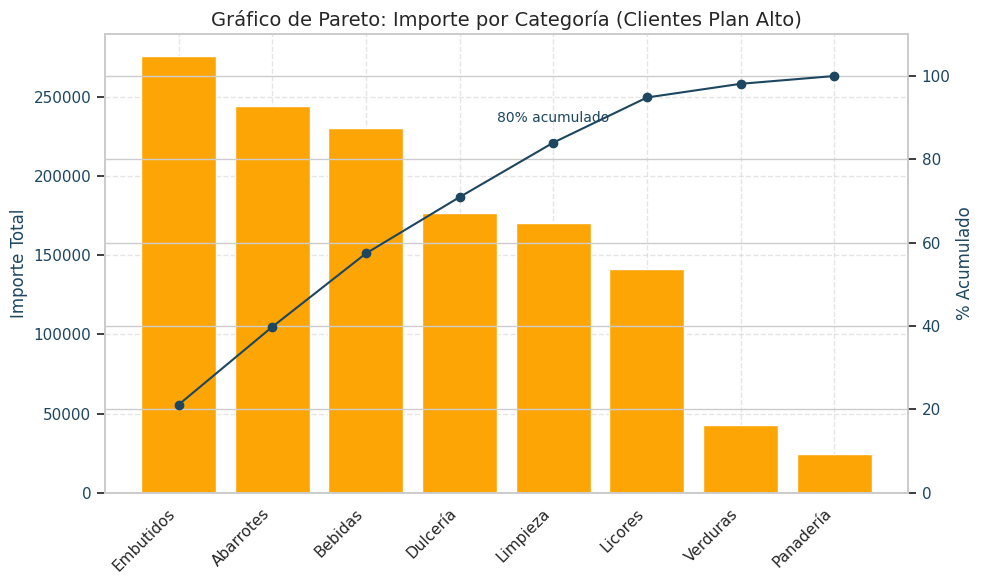

/tmp/ipython-input-2851186210.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pareto_df['categoria'], rotation=45, ha='right')


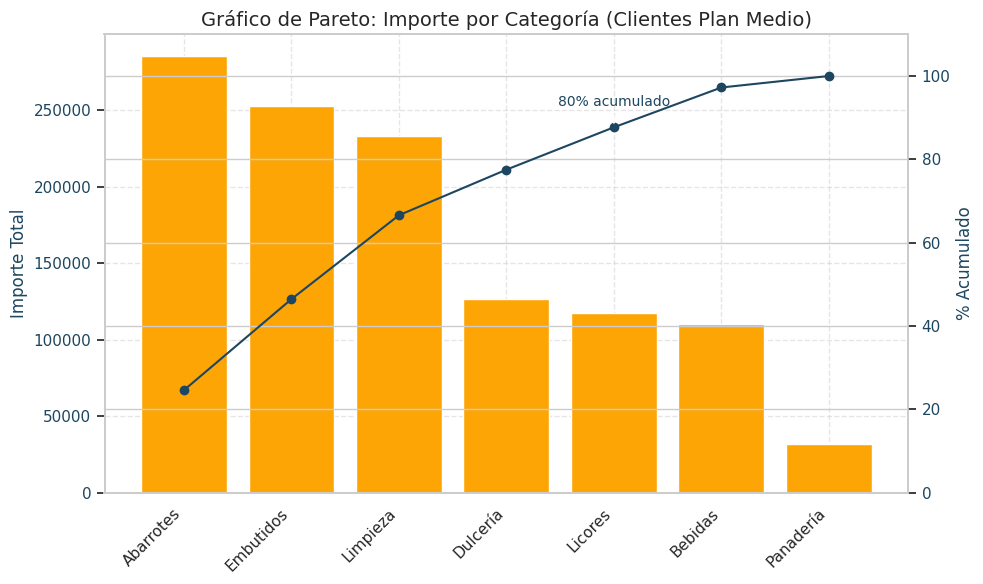

/tmp/ipython-input-2851186210.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pareto_df['categoria'], rotation=45, ha='right')


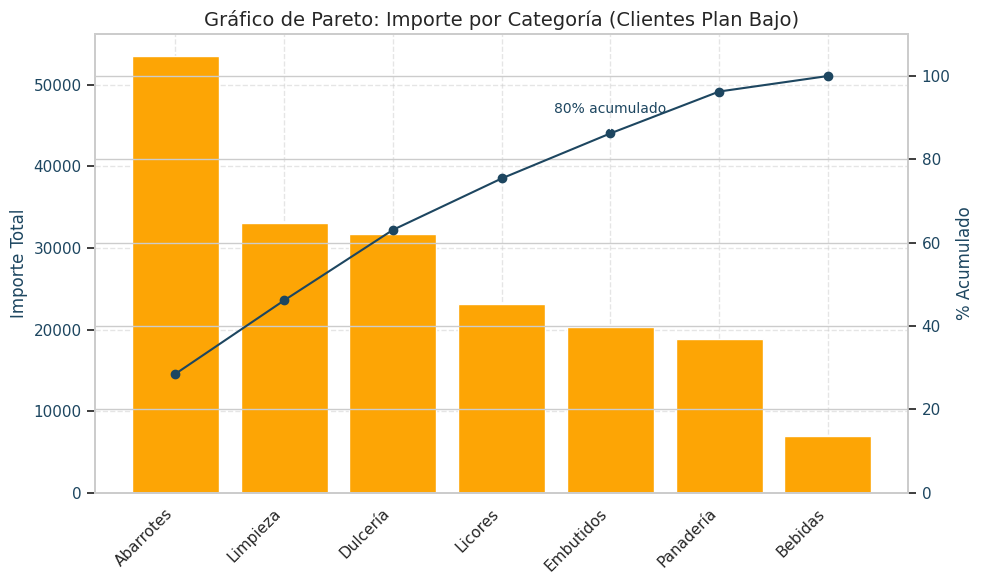

In [ ]:
def graficar_pareto(df, nivel_plan):
    # Filtrar por nivel de plan
    df_filtrado = df[df['Valor_del_Plan'].str.lower() == nivel_plan.lower()]

    # Agrupar por categoría y sumar importe
    pareto_data = df_filtrado.groupby('categoria')['importe'].sum().sort_values(ascending=False)

    # Calcular porcentaje acumulado
    pareto_df = pareto_data.reset_index()
    pareto_df['porcentaje'] = pareto_df['importe'] / pareto_df['importe'].sum() * 100
    pareto_df['porcentaje_acumulado'] = pareto_df['porcentaje'].cumsum()

    # Crear gráfico
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.bar(pareto_df['categoria'], pareto_df['importe'], color='#FDA505')
    ax1.set_ylabel('Importe Total', color='#1D4660')
    ax1.tick_params(axis='y', labelcolor='#1D4660')
    ax1.set_xticklabels(pareto_df['categoria'], rotation=45, ha='right')

    # Línea del porcentaje acumulado
    ax2 = ax1.twinx()
    ax2.plot(pareto_df['categoria'], pareto_df['porcentaje_acumulado'], color='#1D4660', marker='o')
    ax2.set_ylabel('% Acumulado', color='#1D4660')
    ax2.tick_params(axis='y', labelcolor='#1D4660')
    ax2.set_ylim(0, 110)

    # Título y cuadrícula
    plt.title(f'Gráfico de Pareto: Importe por Categoría (Clientes Plan {nivel_plan.capitalize()})', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Etiqueta del 80% acumulado
    corte_80 = pareto_df[pareto_df['porcentaje_acumulado'] >= 80].iloc[0]
    ax2.annotate(
        '80% acumulado',
        xy=(corte_80['categoria'], corte_80['porcentaje_acumulado']),
        xytext=(corte_80['categoria'], corte_80['porcentaje_acumulado'] + 5),
        arrowprops=dict(facecolor='black', arrowstyle='->'),
        fontsize=10,
        color='#1D4660',
        ha='center'
    )

    plt.tight_layout()
    plt.show()

# Ejecutar para cada nivel de plan
for nivel in ['alto', 'medio', 'bajo']:
    graficar_pareto(df, nivel)

 Las principales categorías de productos:

 - **Embutidos**, **abarrotes** y **bebidas** son las categorías son las más relevantes para un cliente con un plan "Alto"
- **Abarrotes**, **embutidos** y **limpieza** para un cliente con un plan "Medio"

 - **Abarrotes** son para un cliente con un plan "Bajo"


In [ ]:
import plotly.graph_objects as go
import plotly.subplots as sp

# Crear figura con dos subplots: histograma arriba, boxplot abajo
fig = sp.make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.3],
    vertical_spacing=0.05
)

# Histograma
fig.add_trace(
    go.Histogram(
        x=df['precio_unitario'],
        nbinsx=30,
        marker_color='#FDA505',
        name='Histograma'
    ),
    row=1, col=1
)

# Boxplot
fig.add_trace(
    go.Box(
        x=df['precio_unitario'],
        marker_color='#FDA505',
        boxpoints='outliers',
        name='Boxplot',
        orientation='h'
    ),
    row=2, col=1
)

# Estilo general
fig.update_layout(
    height=600,
    showlegend=False,
    title_text="Distribución de los precios",
    title_font=dict(size=16, family='Arial', color='black'),
    margin=dict(t=60, l=40, r=40, b=40),
    plot_bgcolor='white'
)

# Ejes y cuadrícula
fig.update_xaxes(showgrid=True, gridcolor='#F6F6F6', linecolor='#989898', tickfont=dict(color='#4f4f4f'))
fig.update_yaxes(showgrid=False, linecolor='#989898', tickfont=dict(color='#4f4f4f'))

fig.show()

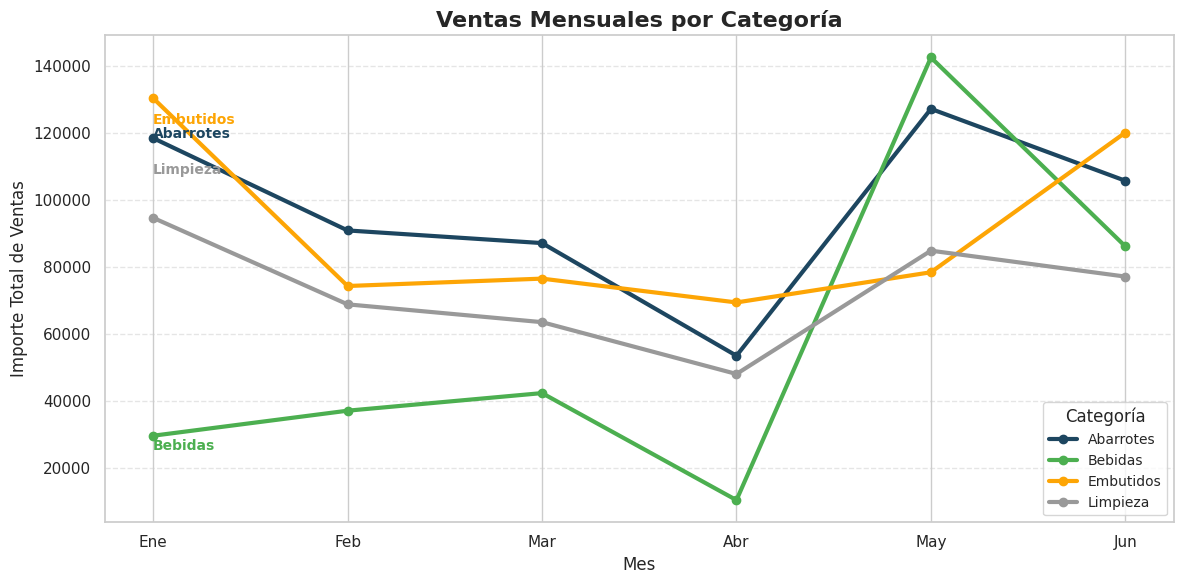

In [ ]:
# Filtrar las categorías deseadas
categorias_deseadas = ['Abarrotes', 'Embutidos', 'Limpieza', 'Bebidas']
ventas_categoria = df[df['categoria'].isin(categorias_deseadas)].copy()

# Convertir 'fecha' a datetime
ventas_categoria['fecha'] = pd.to_datetime(ventas_categoria['fecha'], errors='coerce')

# Extraer el mes
ventas_categoria['month'] = ventas_categoria['fecha'].dt.month

# Agrupar por categoría y mes
ventas_categoria_monthly = ventas_categoria.groupby(['categoria', 'month'])['importe'].sum().reset_index()

# Filtrar solo los primeros 12 meses
ventas_categoria_monthly = ventas_categoria_monthly[ventas_categoria_monthly['month'] <= 12]

# Pivotear para formato de líneas
ventas_pivot = ventas_categoria_monthly.pivot(index='month', columns='categoria', values='importe').sort_index()

# Etiquetas de meses abreviadas
meses = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}
etiquetas = [meses[m] for m in ventas_pivot.index]

# Paleta personalizada
colors = {
    'Abarrotes': '#1D4660',
    'Embutidos': '#FDA505',
    'Limpieza': '#999999',
    'Bebidas': '#4CAF50'
}

# Offsets personalizados
offsets = {
    'Abarrotes': 0.01,
    'Embutidos': -0.05,
    'Limpieza': 0.15,
    'Bebidas': -0.10
}

# Crear gráfico
plt.figure(figsize=(12, 6))

for categoria in ventas_pivot.columns:
    plt.plot(etiquetas, ventas_pivot[categoria], marker='o', linewidth=3,
             label=categoria, color=colors.get(categoria, '#999999'))

    if len(ventas_pivot[categoria]) > 0:
        y_pos = ventas_pivot[categoria].iloc[0]
        offset = y_pos * offsets.get(categoria, 0.05)
        plt.text(etiquetas[0], y_pos + offset,
                 categoria,
                 color=colors.get(categoria, '#999999'),
                 ha='left',
                 va='center',
                 fontsize=10,
                 fontweight='bold')

# Estilo visual
plt.title("Ventas Mensuales por Categoría", fontsize=16, fontweight='bold')
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Importe Total de Ventas", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Categoría", fontsize=10)
plt.tight_layout()
plt.show()

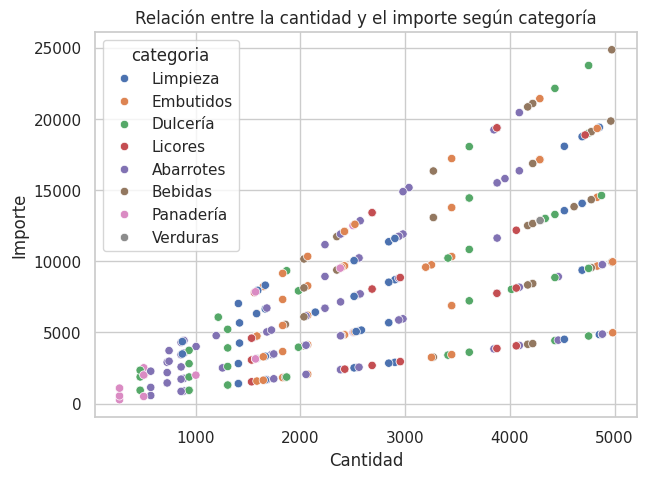

In [ ]:
# Muestra la relación entre dos variables numéricas
# Diferenciando las especies con colores
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="precio_unitario", y="importe", hue="categoria")
plt.title("Relación entre la cantidad y el importe según categoría")
plt.xlabel("Cantidad")
plt.ylabel("Importe")
plt.show()

Las categorías de productos con menor número de demanda es la **Panadería**

#### **Uso de tipo de pago semestral**

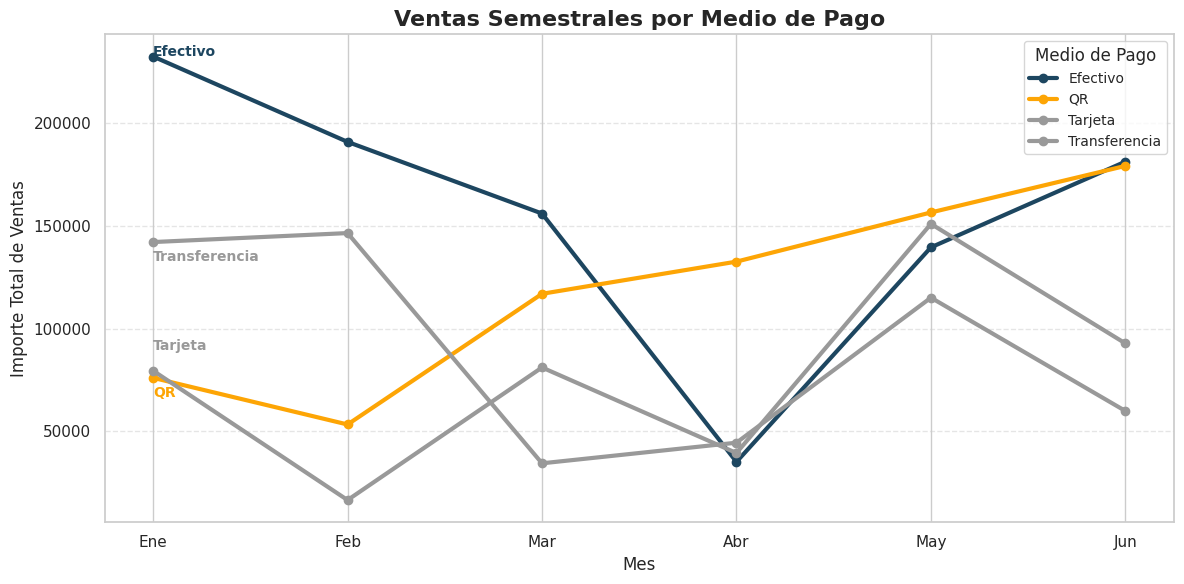

In [ ]:
# Agrupar datos por medio de pago y mes
ventas_medio_pago = df.groupby(['medio_pago', 'fecha'])['importe'].sum().reset_index()

# Convert 'fecha' to datetime objects if they aren't already
ventas_medio_pago['fecha'] = pd.to_datetime(ventas_medio_pago['fecha'])

# Extract the month from the 'fecha' column
ventas_medio_pago['month'] = ventas_medio_pago['fecha'].dt.month

# Group by medio_pago and month to ensure unique index for pivot
ventas_medio_pago_monthly = ventas_medio_pago.groupby(['medio_pago', 'month'])['importe'].sum().reset_index()

# Filter only the first 6 months (this filtering should be applied after the aggregation by month)
ventas_medio_pago_monthly = ventas_medio_pago_monthly[ventas_medio_pago_monthly['month'] <= 13]


# Pivotear para formato de líneas
ventas_pivot = ventas_medio_pago_monthly.pivot(index='month', columns='medio_pago', values='importe').sort_index()

# Etiquetas de meses abreviadas
meses = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}
etiquetas = [meses[m] for m in ventas_pivot.index]

# Paleta personalizada
colors = {
    'Efectivo': '#1D4660',
    'Transferencia': '#999999',
    'Tarjeta': '#999999',
    'QR': '#FDA505'
}

# 🔧 Offsets personalizados por medio de pago
offsets = {
    'Efectivo': 0.01,
    'Transferencia': -0.05,
    'Tarjeta': 0.15,       # más arriba
    'QR': -0.10            # más abajo
}

# Crear gráfico
plt.figure(figsize=(12, 6))

for medio in ventas_pivot.columns:
    plt.plot(etiquetas, ventas_pivot[medio], marker='o', linewidth=3,
             label=medio, color=colors.get(medio, '#999999'))

    # Calculate position for the text label at the start of each line
    # Ensure the text label is placed at the correct y-coordinate corresponding to the first data point
    if medio in ventas_pivot.columns and len(ventas_pivot[medio]) > 0:
        # Use .iloc[0] on the ventas_pivot for the correct starting y-position
        y_pos = ventas_pivot[medio].iloc[0]
        # Adjust offset based on the y-value scale if needed, simple fixed offset for now
        offset = y_pos * offsets.get(medio, 0.05) # Apply offset to the actual y_pos


        plt.text(etiquetas[0], y_pos + offset,
                 medio,
                 color=colors.get(medio, '#999999'),
                 ha='left',
                 va='center',
                 fontsize=10,
                 fontweight='bold')


# Estilo visual
plt.title("Ventas Semestrales por Medio de Pago", fontsize=16, fontweight='bold')
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Importe Total de Ventas", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Medio de Pago", fontsize=10)
plt.tight_layout()
plt.show()

La mayoría de los clientes realizan sus pagos con "QR", y esta cifra tiende a aumentar cada mes. Los pagos en "efectivo" aumentaron los dos últimos meses a pesar que venía disminuyendo en abril. Por otro lado la "tarjeta(de débito, de crédito)" y las "transferencias" tienen una tendencia de uso bajista. Esto se debe probablemente a las altas comisiones que se cobran por costos de cobro que se transfieren al consumidor.

# **6. Resumen**

- Según el comportamiento de los clientes, se puede concluir que suelen adquirir entre 2, 3 y 4 productos.
Los clientes con un plan de consumo de medio a alto residen en Alta Gracia y Río Cuarto. Mientras, que los clientes más críticos residen en Mendiolaza y Villa María.
Por lo tanto, se necesita una estrategia comercial para aumentar el interés de los clientes con llamadas a la acción de acuerdo al perfil del cliente

- Según el análisis las categorías consumidas por los clientes con un "Plan alto" es **Embutidos**, **abarrotes** y **bebidas**, mientras que los clientes con un "Plan Medio" son **Abarrotes**, **embutidos** y **limpieza** y finalmente, los clientes con un "Plan Bajo" solo se sostiene para la categoría abarrrotes **Abarrotes**. A partir de este análisis, se puede desarrollar una estrategia comercial que incluya promociones entre estas categorías segun el perfil de consumo, lo que se espera que incremente las oportunidades de generación de ingresos de la empresa.

- Las pagos con QR y en efectivo son los tipo de pago favoritos de los clientes. Se invita colocar promociones para incentivar estos tipos de pago. Cabe resaltar que los consumidores no desean asumir las comisiones de las transferencias y tarjetas(de crédito, de depósito)